- This notebook is a playground, to perform our analysis on small portion of the data, to understand how things works, then we can transfer our knowledge then to other notebooks.

In [2]:
import sys
sys.path.append('../../Anna_Code')  
from file_helper import *



In [3]:


#load all csv files into one dataframe
#used forQUT S7Comm
# Abdelaziz Comment: It would be better if we added the path as parameter, so I can also use them
def load_all_csvs(attack_path = "/home/dW5kZWFk/uni/study_project/datasets/output/2017QUT_S7comm/attacks/", control_path="/home/dW5kZWFk/uni/study_project/datasets/output/2017QUT_S7comm/control/"):
    # Get all .csv files recursively (or non-recursively)
    csv_files_attack = list_files_by_filetype(attack_path,"csv")
    csv_files_control = list_files_by_filetype(control_path,"csv")
    csv_files=csv_files_attack+csv_files_control
    dfs = []


    for f in csv_files:
        try:
            df = pd.read_csv(f)
            dfs.append(df)
        except Exception as e:
            print(f"⚠️  Skipping {f}: {e}")


    combined = pd.concat(dfs, ignore_index=True)
    print(f"✅ Combined DataFrame shape: {combined.shape}")
    return combined

In [4]:

#for each pcap file create a csv file using the pcap_extract_values function
#no csv created for empty files
def create_csv_files( 
        attack_path = '../../DataSets/2017QUT_S7comm/LabelledDataset/20161215163606_s7_process_attacks',
        control_path='../../DataSets/2017QUT_S7comm/LabelledDataset/20161219132813_control_set'  ,
        output_base_path_attack="/home/dW5kZWFk/uni/study_project/datasets/output/2017QUT_S7comm/attacks/",
        output_base_path_control = "/home/dW5kZWFk/uni/study_project/datasets/output/2017QUT_S7comm/control/"
  
        ):

    pcap_files_attack=list_files_by_filetype(attack_path,"pcap")
    pcap_files_control=list_files_by_filetype(control_path,"pcap")
    print(len(pcap_files_attack))
    print(len(pcap_files_control))

    for path in pcap_files_control:
        try:
            filename = os.path.basename(path)
            df_pcap=pcap_extract_values(path, 0)
            save_df_to_csv(df_pcap, output_base_path_control+filename+".csv")
            print(f"File {path} done.")
        except Exception as e:
            print(f"Exception in {filename}:\n{e}")

    print("\n\nControl dataset done\n\n")

    for path in pcap_files_attack:
        try:
            filename=os.path.basename(path)
            df_pcap = pcap_extract_values(path, 1)
            save_df_to_csv(df_pcap, output_base_path_attack+filename+".csv")
            print(f"File {path} done.")
        except Exception as e:
            print(f"Exception in {path}:\n{e}")
            os.path.getsize(path)

    return 0


In [5]:
# create_csv_files(

#     '../../DataSets/2017QUT_S7comm/LabelledDataset/20161215163606_s7_process_attacks',
#     '../../DataSets/2017QUT_S7comm/LabelledDataset/20161219132813_control_set'  ,
#     '../../DataSets/2017QUT_S7comm/LabelledDataset/output/2017QUT_S7comm/attacks/'  ,
#     '../../DataSets/2017QUT_S7comm/LabelledDataset/output/2017QUT_S7comm/control/'  ,
# )
# This took 24 minutes to run on my PC
# do not run it again unless you need to recreate the csv files

## Creating Traffic flow for Attacker Dataset

In [6]:

df_attacks = load_all_csvs(
    '../../DataSets/2017QUT_S7comm/LabelledDataset/output/2017QUT_S7comm/attacks/',
)

df_attacks.head()

✅ Combined DataFrame shape: (3635038, 15)


,timestamp,src_ip,dst_ip,src_port,dst_port,l4_proto,app_proto,frame_len,total_header_len,app_payload_len,pair_id,iat_pair,iat_proto_pair,label_attack,filename
0,1.481787e+09,10.10.10.66,10.10.10.10,49610,102,TCP,s7comm,90,54,36,10.10.10.10__10.10.10.66,NaN,NaN,1,20161215172609.ConveyorBeltOff.attacker.pcap
1,1.481787e+09,10.10.10.10,10.10.10.66,102,49610,TCP,s7comm,76,54,22,10.10.10.10__10.10.10.66,0.003519,0.003519,1,20161215172609.ConveyorBeltOff.attacker.pcap
2,1.481787e+09,10.10.10.66,10.10.10.10,49610,102,TCP,s7comm,90,54,36,10.10.10.10__10.10.10.66,0.000736,0.000736,1,20161215172609.ConveyorBeltOff.attacker.pcap
3,1.481787e+09,10.10.10.10,10.10.10.66,102,49610,TCP,s7comm,76,54,22,10.10.10.10__10.10.10.66,0.003264,0.003264,1,20161215172609.ConveyorBeltOff.attacker.pcap
4,1.481787e+09,10.10.10.66,10.10.10.10,49610,102,TCP,s7comm,90,54,36,10.10.10.10__10.10.10.66,NaN,NaN,1,20161215172609.ConveyorBeltOff.master.pcap


In [7]:
# select only timestamp, src_ip, dst_ip, l4_proto, app_proto_ frame_len, pair_id, filename 
df_attacks_selected_features = df_attacks[['timestamp', 'src_ip', 'dst_ip', 'app_proto', 'frame_len', 'pair_id']]
df_attacks_selected_features.head()

,timestamp,src_ip,dst_ip,app_proto,frame_len,pair_id
0,1.481787e+09,10.10.10.66,10.10.10.10,s7comm,90,10.10.10.10__10.10.10.66
1,1.481787e+09,10.10.10.10,10.10.10.66,s7comm,76,10.10.10.10__10.10.10.66
2,1.481787e+09,10.10.10.66,10.10.10.10,s7comm,90,10.10.10.10__10.10.10.66
3,1.481787e+09,10.10.10.10,10.10.10.66,s7comm,76,10.10.10.10__10.10.10.66
4,1.481787e+09,10.10.10.66,10.10.10.10,s7comm,90,10.10.10.10__10.10.10.66


In [8]:
# show the unique app_proto
print(df_attacks_selected_features['app_proto'].unique())

['s7comm' 'undetected:-1:-1' 'DHCPv6 Client' 'NBDS' 'NTP' 'NBNS' 'mDNS'
 'llmnr']


In [9]:
# drop any packet with undefined app_proto and any packet with no src_ip or dst_ip
df_attacks_selected_features = df_attacks_selected_features[df_attacks_selected_features['app_proto'] != 'undetected:-1:-1']
df_attacks_selected_features = df_attacks_selected_features[df_attacks_selected_features['src_ip'].notna() & df_attacks_selected_features['dst_ip'].notna()]
print(df_attacks_selected_features.head())


      timestamp       src_ip       dst_ip app_proto  frame_len  \
0  1.481787e+09  10.10.10.66  10.10.10.10    s7comm         90   
1  1.481787e+09  10.10.10.10  10.10.10.66    s7comm         76   
2  1.481787e+09  10.10.10.66  10.10.10.10    s7comm         90   
3  1.481787e+09  10.10.10.10  10.10.10.66    s7comm         76   
4  1.481787e+09  10.10.10.66  10.10.10.10    s7comm         90   

                    pair_id  
0  10.10.10.10__10.10.10.66  
1  10.10.10.10__10.10.10.66  
2  10.10.10.10__10.10.10.66  
3  10.10.10.10__10.10.10.66  
4  10.10.10.10__10.10.10.66  


In [10]:
# group packets by application protocol
df_attacks_grouped = df_attacks_selected_features.groupby(['app_proto', 'pair_id'])

df_attacks_grouped.head()

,timestamp,src_ip,dst_ip,app_proto,frame_len,pair_id
0,1.481787e+09,10.10.10.66,10.10.10.10,s7comm,90,10.10.10.10__10.10.10.66
1,1.481787e+09,10.10.10.10,10.10.10.66,s7comm,76,10.10.10.10__10.10.10.66
2,1.481787e+09,10.10.10.66,10.10.10.10,s7comm,90,10.10.10.10__10.10.10.66
3,1.481787e+09,10.10.10.10,10.10.10.66,s7comm,76,10.10.10.10__10.10.10.66
4,1.481787e+09,10.10.10.66,10.10.10.10,s7comm,90,10.10.10.10__10.10.10.66
36,1.481789e+09,10.10.10.20,10.10.10.10,s7comm,301,10.10.10.10__10.10.10.20
37,1.481789e+09,10.10.10.20,10.10.10.10,s7comm,85,10.10.10.10__10.10.10.20
41,1.481789e+09,10.10.10.20,10.10.10.10,s7comm,301,10.10.10.10__10.10.10.20
42,1.481789e+09,10.10.10.20,10.10.10.10,s7comm,85,10.10.10.10__10.10.10.20
100,1.481796e+09,10.10.10.20,10.10.10.10,s7comm,301,10.10.10.10__10.10.10.20


In [11]:
flows_attacker = df_attacks_grouped.apply(lambda x: x[['timestamp', 'src_ip', 'dst_ip', 'frame_len']].sort_values('timestamp').reset_index(drop=True))

# convert timestamp to datetime
flows_attacker['timestamp'] = pd.to_datetime(flows_attacker['timestamp'], unit='s')

flows_attacker.head()

C:\Users\20115\AppData\Local\Temp\ipykernel_27412\3962883847.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  flows_attacker = df_attacks_grouped.apply(lambda x: x[['timestamp', 'src_ip', 'dst_ip', 'frame_len']].sort_values('timestamp').reset_index(drop=True))


timestamp  \
app_proto pair_id                                                     
NBDS      10.10.10.20__10.10.10.255 0 2016-12-15 06:36:11.747622013   
                                    1 2016-12-15 06:36:11.747644901   
                                    2 2016-12-15 06:36:11.747797966   
                                    3 2016-12-15 06:41:02.034471989   
                                    4 2016-12-15 06:41:02.034490108   

                                            src_ip        dst_ip  frame_len  
app_proto pair_id                                                            
NBDS      10.10.10.20__10.10.10.255 0  10.10.10.20  10.10.10.255        243  
                                    1  10.10.10.20  10.10.10.255        243  
                                    2  10.10.10.20  10.10.10.255        243  
                                    3  10.10.10.20  10.10.10.255        255  
                                    4  10.10.10.20  10.10.10.255        255

In [12]:
# add inter-arrival packet time between packets in the same flow
flows_attacker['iat'] = flows_attacker.groupby(level=[0,1])['timestamp'].diff().dt.total_seconds()
flows_attacker.head()




timestamp  \
app_proto pair_id                                                     
NBDS      10.10.10.20__10.10.10.255 0 2016-12-15 06:36:11.747622013   
                                    1 2016-12-15 06:36:11.747644901   
                                    2 2016-12-15 06:36:11.747797966   
                                    3 2016-12-15 06:41:02.034471989   
                                    4 2016-12-15 06:41:02.034490108   

                                            src_ip        dst_ip  frame_len  \
app_proto pair_id                                                             
NBDS      10.10.10.20__10.10.10.255 0  10.10.10.20  10.10.10.255        243   
                                    1  10.10.10.20  10.10.10.255        243   
                                    2  10.10.10.20  10.10.10.255        243   
                                    3  10.10.10.20  10.10.10.255        255   
                                    4  10.10.10.20  10.10.10.255        255   

                                              iat  
app_proto pair_id                                  
NBDS      10.10.10.20__10.10.10.255 0         NaN  
                                    1    0.000023  
                                    2    0.000153  
                                    3  290.286674  
                                    4    0.000018

In [13]:
# print basic info about the flows dataframe
print(len(flows_attacker))
print(type(flows_attacker))
print(flows_attacker.shape)
print(flows_attacker.columns)
print(flows_attacker.index)


3574782
<class 'pandas.core.frame.DataFrame'>
(3574782, 5)
Index(['timestamp', 'src_ip', 'dst_ip', 'frame_len', 'iat'], dtype='object')
MultiIndex([(  'NBDS', '10.10.10.20__10.10.10.255',       0),
            (  'NBDS', '10.10.10.20__10.10.10.255',       1),
            (  'NBDS', '10.10.10.20__10.10.10.255',       2),
            (  'NBDS', '10.10.10.20__10.10.10.255',       3),
            (  'NBDS', '10.10.10.20__10.10.10.255',       4),
            (  'NBDS', '10.10.10.20__10.10.10.255',       5),
            (  'NBDS', '10.10.10.20__10.10.10.255',       6),
            (  'NBDS', '10.10.10.20__10.10.10.255',       7),
            (  'NBDS', '10.10.10.20__10.10.10.255',       8),
            (  'NBDS', '10.10.10.20__10.10.10.255',       9),
            ...
            ('s7comm',  '10.10.10.10__10.10.10.66', 2707153),
            ('s7comm',  '10.10.10.10__10.10.10.66', 2707154),
            ('s7comm',  '10.10.10.10__10.10.10.66', 2707155),
            ('s7comm',  '10.10.10.10__10.1

In [14]:
unique_indices_attacker = flows_attacker.index.droplevel(-1).unique()
print(unique_indices_attacker)
print(len(unique_indices_attacker))


MultiIndex([(  'NBDS',       '10.10.10.20__10.10.10.255'),
            (  'NBNS',       '10.10.10.20__10.10.10.255'),
            (  'NBNS', '169.254.133.89__169.254.255.255'),
            (   'NTP',   '10.10.10.200__255.255.255.255'),
            ( 'llmnr',        '10.10.10.20__224.0.0.252'),
            ( 'llmnr',     '169.254.133.89__224.0.0.252'),
            (  'mDNS',        '10.10.10.66__224.0.0.251'),
            ('s7comm',        '10.10.10.10__10.10.10.20'),
            ('s7comm',        '10.10.10.10__10.10.10.66')],
           names=['app_proto', 'pair_id'])
9


In [15]:
# Print the length for each flow  => now this is a problem, because it was mentioned that all flows should have the same length.
flow_lengths = flows_attacker.groupby(level=[0,1]).size()
print(flow_lengths)

app_proto  pair_id                        
NBDS       10.10.10.20__10.10.10.255              243
NBNS       10.10.10.20__10.10.10.255              117
           169.254.133.89__169.254.255.255        162
NTP        10.10.10.200__255.255.255.255         1395
llmnr      10.10.10.20__224.0.0.252                72
           169.254.133.89__224.0.0.252            108
mDNS       10.10.10.66__224.0.0.251                30
s7comm     10.10.10.10__10.10.10.20            865492
           10.10.10.10__10.10.10.66           2707163
dtype: int64


In [ ]:
# create traffic flows with time window 2 minutes, 4 minutes, and finally 6 minutes
def create_time_windowed_flows(flows, time_window_minutes):
    time_windowed_flows = {}
    time_delta = pd.Timedelta(minutes=time_window_minutes)
    
    for (app_proto, pair_id), group in flows.groupby(level=[0,1]):
        start_time = group['timestamp'].min()
        end_time = group['timestamp'].max()
        
        current_window_start = start_time
        while current_window_start < end_time:
            current_window_end = current_window_start + time_delta
            window_group = group[(group['timestamp'] >= current_window_start) & (group['timestamp'] < current_window_end)]
            
            if not window_group.empty:
                key = (app_proto, pair_id, current_window_start)
                time_windowed_flows[key] = window_group.reset_index(drop=True)
            
            current_window_start = current_window_end
            
    # convert the result to a DataFrame with MultiIndex
    df = pd.concat(time_windowed_flows.values(), keys=time_windowed_flows.keys())
    return df
flows_attacker_2min = create_time_windowed_flows(flows_attacker, 2)
flows_attacker_4min = create_time_windowed_flows(flows_attacker, 4)
flows_attacker_6min = create_time_windowed_flows(flows_attacker, 6)

In [22]:
# print flows
print(f"Number of 2-minute flows (attacker): {len(flows_attacker_2min)}")
print(f"Number of 4-minute flows (attacker): {len(flows_attacker_4min)}")
print(f"Number of 6-minute flows (attacker): {len(flows_attacker_6min)}")

flows_attacker_2min.head()

Number of 2-minute flows (attacker): 3574782
Number of 4-minute flows (attacker): 3574782
Number of 6-minute flows (attacker): 3574782


timestamp  \
NBDS 10.10.10.20__10.10.10.255 2016-12-15 06:36:11.747622013 0 2016-12-15 06:36:11.747622013   
                                                             1 2016-12-15 06:36:11.747644901   
                                                             2 2016-12-15 06:36:11.747797966   
                               2016-12-15 06:40:11.747622013 0 2016-12-15 06:41:02.034471989   
                                                             1 2016-12-15 06:41:02.034490108   

                                                                     src_ip  \
NBDS 10.10.10.20__10.10.10.255 2016-12-15 06:36:11.747622013 0  10.10.10.20   
                                                             1  10.10.10.20   
                                                             2  10.10.10.20   
                               2016-12-15 06:40:11.747622013 0  10.10.10.20   
                                                             1  10.10.10.20   

                                                                      dst_ip  \
NBDS 10.10.10.20__10.10.10.255 2016-12-15 06:36:11.747622013 0  10.10.10.255   
                                                             1  10.10.10.255   
                                                             2  10.10.10.255   
                               2016-12-15 06:40:11.747622013 0  10.10.10.255   
                                                             1  10.10.10.255   

                                                                frame_len  \
NBDS 10.10.10.20__10.10.10.255 2016-12-15 06:36:11.747622013 0        243   
                                                             1        243   
                                                             2        243   
                               2016-12-15 06:40:11.747622013 0        255   
                                                             1        255   

                                                                       iat  
NBDS 10.10.10.20__10.10.10.255 2016-12-15 06:36:11.747622013 0         NaN  
                                                             1    0.000023  
                                                             2    0.000153  
                               2016-12-15 06:40:11.747622013 0  290.286674  
                                                             1    0.000018

## Same analysis but for control data

In [24]:
df_control = load_all_csvs(
    '../../DataSets/2017QUT_S7comm/LabelledDataset/output/2017QUT_S7comm/control/',
)   

df_control.head()

✅ Combined DataFrame shape: (870682, 15)


,timestamp,src_ip,dst_ip,src_port,dst_port,l4_proto,app_proto,frame_len,total_header_len,app_payload_len,pair_id,iat_pair,iat_proto_pair,label_attack,filename
0,1.482118e+09,NaN,NaN,-1,-1,unknown,undetected:-1:-1,158,158,0,__,NaN,NaN,0,attacker.pcap
1,1.482118e+09,NaN,NaN,-1,-1,unknown,undetected:-1:-1,60,60,0,__,2.101597,2.101597,0,attacker.pcap
2,1.482118e+09,NaN,NaN,-1,-1,unknown,undetected:-1:-1,60,60,0,__,0.001042,0.001042,0,attacker.pcap
3,1.482118e+09,NaN,NaN,-1,-1,unknown,undetected:-1:-1,60,60,0,__,0.001972,0.001972,0,attacker.pcap
4,1.482118e+09,NaN,NaN,-1,-1,unknown,undetected:-1:-1,153,153,0,__,0.976897,0.976897,0,attacker.pcap


In [25]:
# select only timestamp, src_ip, dst_ip, l4_proto, app_proto_ frame_len, pair_id, filename
df_control_selected_features = df_control[['timestamp', 'src_ip', 'dst_ip', 'app_proto', 'frame_len', 'pair_id']]

In [26]:
# print unique app_proto
print(df_control_selected_features['app_proto'].unique())

['undetected:-1:-1' 'NTP' 'NBNS' 'NBDS' 'DHCPv6 Client' 'llmnr' 's7comm']


In [27]:

df_control_selected_features = df_control_selected_features[df_control_selected_features['app_proto'] != 'undetected:-1:-1']
df_control_selected_features = df_control_selected_features[df_control_selected_features['src_ip'].notna() & df_control_selected_features['dst_ip'].notna()]
print(df_control_selected_features.head())

       timestamp        src_ip           dst_ip app_proto  frame_len  \
8   1.482118e+09  10.10.10.200  255.255.255.255       NTP         90   
16  1.482118e+09  10.10.10.200  255.255.255.255       NTP         90   
18  1.482118e+09   10.10.10.20     10.10.10.255      NBNS         92   
19  1.482118e+09   10.10.10.20     10.10.10.255      NBNS         92   
21  1.482118e+09   10.10.10.20     10.10.10.255      NBNS         92   

                          pair_id  
8   10.10.10.200__255.255.255.255  
16  10.10.10.200__255.255.255.255  
18      10.10.10.20__10.10.10.255  
19      10.10.10.20__10.10.10.255  
21      10.10.10.20__10.10.10.255  


In [28]:
# same for control data
df_control_grouped = df_control_selected_features.groupby(['app_proto', 'pair_id'])

df_control_grouped.head()

,timestamp,src_ip,dst_ip,app_proto,frame_len,pair_id
8,1.482118e+09,10.10.10.200,255.255.255.255,NTP,90,10.10.10.200__255.255.255.255
16,1.482118e+09,10.10.10.200,255.255.255.255,NTP,90,10.10.10.200__255.255.255.255
18,1.482118e+09,10.10.10.20,10.10.10.255,NBNS,92,10.10.10.20__10.10.10.255
19,1.482118e+09,10.10.10.20,10.10.10.255,NBNS,92,10.10.10.20__10.10.10.255
21,1.482118e+09,10.10.10.20,10.10.10.255,NBNS,92,10.10.10.20__10.10.10.255
25,1.482118e+09,10.10.10.200,255.255.255.255,NTP,90,10.10.10.200__255.255.255.255
33,1.482118e+09,10.10.10.200,255.255.255.255,NTP,90,10.10.10.200__255.255.255.255
40,1.482118e+09,10.10.10.200,255.255.255.255,NTP,90,10.10.10.200__255.255.255.255
148,1.482118e+09,10.10.10.20,10.10.10.255,NBDS,255,10.10.10.20__10.10.10.255
391,1.482119e+09,10.10.10.20,10.10.10.255,NBDS,243,10.10.10.20__10.10.10.255


In [29]:
flows_control = df_control_grouped.apply(lambda x: x[['timestamp', 'src_ip', 'dst_ip', 'frame_len']].sort_values('timestamp').reset_index(drop=True))

# convert timestamp to datetime
flows_control['timestamp'] = pd.to_datetime(flows_control['timestamp'], unit='s')

flows_control.head()

C:\Users\20115\AppData\Local\Temp\ipykernel_27412\1129284589.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  flows_control = df_control_grouped.apply(lambda x: x[['timestamp', 'src_ip', 'dst_ip', 'frame_len']].sort_values('timestamp').reset_index(drop=True))


timestamp  \
app_proto pair_id                                                     
NBDS      10.10.10.20__10.10.10.255 0 2016-12-19 03:30:47.617880106   
                                    1 2016-12-19 03:30:47.617912054   
                                    2 2016-12-19 03:30:47.617969990   
                                    3 2016-12-19 03:35:05.012423992   
                                    4 2016-12-19 03:35:05.012454987   

                                            src_ip        dst_ip  frame_len  
app_proto pair_id                                                            
NBDS      10.10.10.20__10.10.10.255 0  10.10.10.20  10.10.10.255        255  
                                    1  10.10.10.20  10.10.10.255        255  
                                    2  10.10.10.20  10.10.10.255        255  
                                    3  10.10.10.20  10.10.10.255        243  
                                    4  10.10.10.20  10.10.10.255        243

In [30]:

flows_control['iat'] = flows_control.groupby(level=[0,1])['timestamp'].diff().dt.total_seconds()
flows_control.head()

timestamp  \
app_proto pair_id                                                     
NBDS      10.10.10.20__10.10.10.255 0 2016-12-19 03:30:47.617880106   
                                    1 2016-12-19 03:30:47.617912054   
                                    2 2016-12-19 03:30:47.617969990   
                                    3 2016-12-19 03:35:05.012423992   
                                    4 2016-12-19 03:35:05.012454987   

                                            src_ip        dst_ip  frame_len  \
app_proto pair_id                                                             
NBDS      10.10.10.20__10.10.10.255 0  10.10.10.20  10.10.10.255        255   
                                    1  10.10.10.20  10.10.10.255        255   
                                    2  10.10.10.20  10.10.10.255        255   
                                    3  10.10.10.20  10.10.10.255        243   
                                    4  10.10.10.20  10.10.10.255        243   

                                              iat  
app_proto pair_id                                  
NBDS      10.10.10.20__10.10.10.255 0         NaN  
                                    1    0.000032  
                                    2    0.000058  
                                    3  257.394454  
                                    4    0.000031

In [31]:
unique_indices_control = flows_control.index.droplevel(-1).unique()
print(unique_indices_control)
print(len(unique_indices_control))


MultiIndex([(  'NBDS',       '10.10.10.20__10.10.10.255'),
            (  'NBNS',       '10.10.10.20__10.10.10.255'),
            (  'NBNS', '169.254.133.89__169.254.255.255'),
            (   'NTP',   '10.10.10.200__255.255.255.255'),
            ( 'llmnr',        '10.10.10.20__224.0.0.252'),
            ( 'llmnr',     '169.254.133.89__224.0.0.252'),
            ('s7comm',        '10.10.10.10__10.10.10.20')],
           names=['app_proto', 'pair_id'])
7


In [32]:

# Print the length for each flow  => now this is a problem, because it was mentioned that all flows should have the same length.
flow_lengths = flows_control.groupby(level=[0,1]).size()
print(flow_lengths)

app_proto  pair_id                        
NBDS       10.10.10.20__10.10.10.255             225
NBNS       10.10.10.20__10.10.10.255             126
           169.254.133.89__169.254.255.255       198
NTP        10.10.10.200__255.255.255.255       11223
llmnr      10.10.10.20__224.0.0.252               78
           169.254.133.89__224.0.0.252            96
s7comm     10.10.10.10__10.10.10.20           785082
dtype: int64


In [33]:

flows_control_2min = create_time_windowed_flows(flows_control, 2)
flows_control_4min = create_time_windowed_flows(flows_control, 4)
flows_control_6min = create_time_windowed_flows(flows_control, 6)
print(f"Number of 2-minute flows (control): {len(flows_control_2min)}")
print(f"Number of 4-minute flows (control): {len(flows_control_4min)}")
print(f"Number of 6-minute flows (control): {len(flows_control_6min)}")

Number of 2-minute flows (control): 797028
Number of 4-minute flows (control): 797028
Number of 6-minute flows (control): 797028


## Task2.b: Calculating Chebyshev distance. 
- Using the flows generated for each of the time intervals, our piece of code should compute the Chebyshev distance between every two generated flows per time interval. For the computation of Chebyshev distance, we are not allowed to use any existing libraries, i.e., the programming logic should be implemented by us. We should compute Chebyshev distance between either two flows without attacks or two flows with attack (but not between flow with attack and flow without attack).

- So lets understand what is Chebyshev distance first
- From the Data Mining lecture provided by Professor Ingo Schmitt
  - 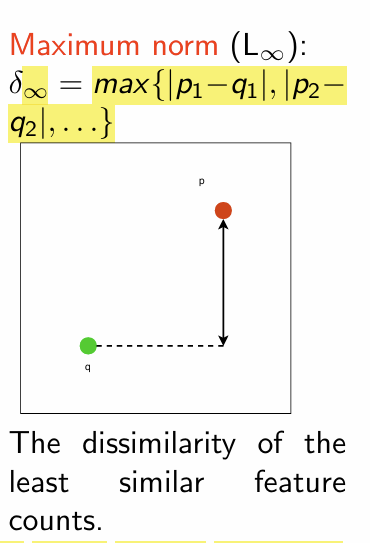
- The Chebyshev distance is a metric used to measure how different two data points (or flows) are by looking only at the largest absolute difference between their corresponding features.
- So, we should compute the absolute difference for every feature and then take the maximum of these differences.
- For example if A = [3,8,2] and B = [1,10,5], then Chebyshev distance is max((|3-1|), |8-10|, |5-2|) = 3